In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
from cryo_sbi import MultiParticleCryoEmSimulator, CryoEmSimulator
import torch
import numpy as np
import matplotlib.pyplot as plt


In [21]:
sim = MultiParticleCryoEmSimulator('/home/dingeldein/Desktop/cryo_em_SBI/conf/image/multi_particle.yaml', device='cpu')
images2, params = sim.sample_and_simulate(num_sim=100, return_parameters=True)

In [ ]:
sim = CryoEmSimulator('tests/config_files/image_params_multi_particle.json', device='cpu')
images2, params = sim.simulate(num_sim=100, return_parameters=True)

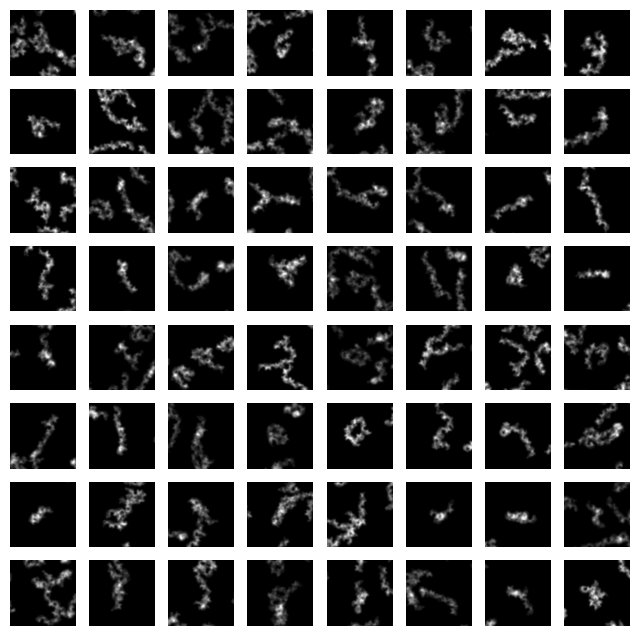

In [22]:
fig, axes = plt.subplots(8, 8, figsize=(8, 8))

for idx, ax in enumerate(axes.flatten()):
    ax.imshow(images2[idx].cpu().numpy(), cmap='gray')
    ax.axis('off')

In [ ]:
images2

In [ ]:
from cryo_sbi.inference.train import  train_classifier_multi_particle, train_classifier

In [ ]:
train_classifier_multi_particle(
    image_config='tests/config_files/image_params_multi_particle.json',
    train_config='/home/dingeldein/Desktop/cryo_em_SBI/tests/config_files/training_params_proto.json',
    epochs=100,
    estimator_file="test_estimaotr_mp.pt",
    loss_file= "test_loss_mp.pt",
    n_workers=20,
    device="cuda",
    simulation_batch_size = 1024,
)

In [ ]:
train_classifier(
    image_config='tests/config_files/image_params_multi_particle.json',
    train_config='/home/dingeldein/Desktop/cryo_em_SBI/tests/config_files/training_params_proto.json',
    epochs=100,
    estimator_file="test_estimaotr_sp.pt",
    loss_file= "test_loss_sp.pt",
    n_workers=20,
    device="cuda",
    simulation_batch_size = 1024,
)